In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh, inv
from scipy.linalg import pinv
from numba import njit
import numpy as np

In [3]:
def compute_covariance(X0):
    return np.cov(X0, rowvar=False)

In [31]:
def compute_gene_difference_covariance(x1_all, x2_all, time_index, twin=True):
    """
    Computes the covariance matrix of gene-wise differences between twin simulations
    (or between randomly paired cells if twin=False).

    Parameters
    ----------
    x1_all : ndarray, shape (n_cells, n_timepoints, n_genes)
        Simulation results for twin 1.
    x2_all : ndarray, shape (n_cells, n_timepoints, n_genes)
        Simulation results for twin 2.
    time_index : int
        Time point at which to compute differences.
    twin : bool, default=True
        If True, compares twins directly.
        If False, compares random pairs (shuffles x1 before differencing).

    Returns
    -------
    cov_matrix : ndarray, shape (n_genes, n_genes)
        Covariance matrix of gene-wise differences (x1 - x2).
    """
    # Get values at the given time point
    x1_t = x1_all[:, time_index, :]
    x2_t = x2_all[:, time_index, :]

    # Compute differences
    if not twin:
        x1_t = np.random.permutation(x1_t)  # shuffle x1 across cells

    diffs = x1_t - x2_t  # shape: (n_cells, n_genes)

    # Covariance of differences
    return np.cov(diffs, rowvar=False)



In [39]:
# Parameters
N = 2
T = 300
dt = 0.05
timesteps = int(T / dt)
lambda_base = 1.0
D = 0.5
epsilon = 1/(N)**.5*(1.-.05)  # subcritical but close to transition
# epsilon = 1/(N)**.5  # subcritical but close to transition
# epsilon = 1/(N)**.5*(1.+.05)  # subcritical but close to transition
np.random.seed(42)
K = np.random.normal(0, 1.0, size=(N, N)) - 1
# K = np.zeros(shape=(N, N))
# K = (K + K.T) / 2  # symmetrize
np.fill_diagonal(K, 0)
A = lambda_base * np.eye(N) + epsilon * K

# Compute the smallest real part of the eigenvalues of A
eigvals = np.linalg.eigvals(A)
lambda_min = np.min(np.real(eigvals))

# Estimate relaxation time
relax_time = 10 / lambda_min  # heuristic: ~5 relaxation times to reach steady state
# T = relax_time
# timesteps = int(T/dt)
print(f"Minimum eigenvalue of A (Re part): {lambda_min:.4f}")
print(f"Recommended minimum simulation time for relaxation: T ≳ {relax_time:.2f}")

@njit(fastmath=True)
def simulate_ou(A, u, with_input, timesteps, N, D, dt, x0=None):
    x = np.zeros((timesteps, N))
    
    # Set initial condition
    if x0 is not None:
        x[0] = x0

    sqrt_2Ddt = np.sqrt(2 * D * dt)
    zero_vec = np.zeros(N)
    force = u if with_input else zero_vec

    for t in range(1, timesteps):
        noise = np.random.normal(0.0, 1.0, N)
        dx = (-A @ x[t - 1] + force) * dt + sqrt_2Ddt * noise
        x[t] = x[t - 1] + dx

    return x


n_cells = 10000  # number of samples
samples = np.zeros((n_cells, N))

# Step 1: Draw initial states from some distribution (e.g., steady state OU)
for i in range(n_cells):
    x = simulate_ou(A, u, False, timesteps, N, D, dt)
    samples[i] = x[-1]  # Use final state as steady-state sample

# Step 2: Simulate twins starting from the same initial state
x1_all = np.zeros((n_cells, timesteps, N))
x2_all = np.zeros((n_cells, timesteps, N))

for i in range(n_cells):
    x0 = samples[i]
    x1_all[i] = simulate_ou(A, u, False, timesteps, N, D, dt, x0=x0)
    x2_all[i] = simulate_ou(A, u, False, timesteps, N, D, dt, x0=x0)

Minimum eigenvalue of A (Re part): 0.5746
Recommended minimum simulation time for relaxation: T ≳ 17.40


In [20]:
# Get values at time index 10 for all cells
x1_t10 = x1_all[:, 10, :]  # shape: (n_cells, N)
x2_t10 = x2_all[:, 10, :]  # shape: (n_cells, N)

# Concatenate x1_t10 and x2_t10 along the last axis
x_combined = np.concatenate((x1_t10, x2_t10), axis=0)  # shape: (n_cells, 2 * N)

cov = compute_covariance(x_combined)
cov

array([[0.67476923, 0.30718291],
       [0.30718291, 0.60442411]])

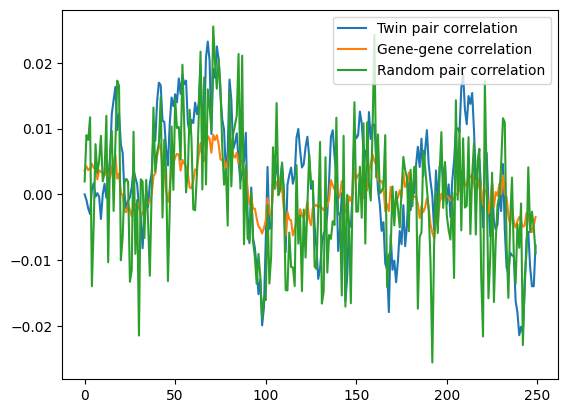

In [38]:
twin_pair_correlation = []
gene_gene_correlation = []
random_pair_correlation = []
time_points = np.arange(0, 250)
for time in time_points:
    x1_at_time = x1_all[:, time, :]  # shape: (n_cells, N)
    x2_at_time = x2_all[:, time, :]  # shape: (n_cells, N)
    x_combined = np.concatenate((x1_at_time, x2_at_time), axis=0)  # shape: (n_cells, 2 * N)
    cov = compute_covariance(x_combined)[0, 1]
    gene_gene_correlation.append(cov)
    # Concatenate x1_t10 and x2_t10 along the last axis
    x_combined = np.concatenate((x1_t10, x2_t10), axis=0)  # shape: (n_cells, 2 * N)
    twin_pair_correlation.append(compute_gene_difference_covariance(x1_all, x2_all, time, twin=True)[0, 1])
    random_pair_correlation.append(compute_gene_difference_covariance(x1_all, x2_all, time, twin=False)[0, 1])

plt.plot(time_points, twin_pair_correlation, label = "Twin pair correlation")
plt.plot(time_points, gene_gene_correlation, label = "Gene-gene correlation")
plt.plot(time_points, random_pair_correlation, label = "Random pair correlation")
plt.legend()
plt.show()

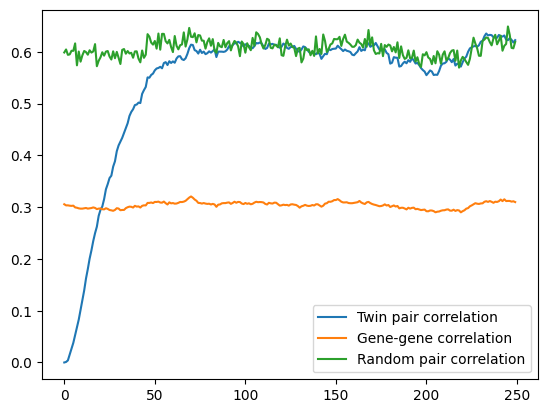

In [40]:
twin_pair_correlation = []
gene_gene_correlation = []
random_pair_correlation = []
time_points = np.arange(0, 250)
for time in time_points:
    x1_at_time = x1_all[:, time, :]  # shape: (n_cells, N)
    x2_at_time = x2_all[:, time, :]  # shape: (n_cells, N)
    x_combined = np.concatenate((x1_at_time, x2_at_time), axis=0)  # shape: (n_cells, 2 * N)
    cov = compute_covariance(x_combined)[0, 1]
    gene_gene_correlation.append(cov)
    # Concatenate x1_t10 and x2_t10 along the last axis
    x_combined = np.concatenate((x1_t10, x2_t10), axis=0)  # shape: (n_cells, 2 * N)
    twin_pair_correlation.append(compute_gene_difference_covariance(x1_all, x2_all, time, twin=True)[0, 1])
    random_pair_correlation.append(compute_gene_difference_covariance(x1_all, x2_all, time, twin=False)[0, 1])

plt.plot(time_points, twin_pair_correlation, label = "Twin pair correlation")
plt.plot(time_points, gene_gene_correlation, label = "Gene-gene correlation")
plt.plot(time_points, random_pair_correlation, label = "Random pair correlation")
plt.legend()
plt.show()